In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from numpy.random import standard_t, normal

import robust_filter

reload(robust_filter)

from data_processing import daily_stock_std
from robust_filter import Filter, score_func, kalman_func

Generate data

In [7]:
N = 500

# True system parameters (unknown to filter)
mu_0_true = 0
theta_true = 0.9
nu_true = 20
sigma_true = 0.2
process_noise_std = 0.8  # Standard deviation of process noise

In [8]:
# Generate true latent state process: AR(1) with Gaussian process noise
process_noise = normal(0, process_noise_std, N - 1)
mu_true = [mu_0_true]
for e in process_noise:
    mu_t = mu_true[-1]
    mu_next = theta_true * mu_t + e
    mu_true.append(mu_next)
print(f"True state mean: {np.mean(mu_true):.3f}, std: {np.std(mu_true):.3f}")

True state mean: -0.114, std: 1.616


In [9]:
# Generate measurement noise: Student-t distribution (robust to outliers)
measurement_noise = standard_t(nu_true, N) * sigma_true
print(
    f"Noise mean: {np.mean(measurement_noise):.3f}, std: {np.std(measurement_noise):.3f}"
)

Noise mean: -0.005, std: 0.212


In [10]:
# Generate observations: true state + measurement noise
y = [m + n for m, n in zip(mu_true, measurement_noise)]
print(f"Observation mean: {np.mean(y):.3f}, std: {np.std(y):.3f}")

Observation mean: -0.120, std: 1.631


Parameter estimation

In [11]:
from parameter_estimation import generate_param_grid, grid_search

In [ ]:
param_grid = {
    "nu": np.arange(15, 25, 1),
    "sigma": np.arange(0.1, 0.5, 0.1),
    "theta": np.arange(0.5, 1.0, 0.1),
    "kappa": np.arange(0.1, 1.0, 0.1),
}
param_dicts = generate_param_grid(param_grid)

In [13]:
best_params_score = grid_search(y, y[0], param_dicts, score_func)

In [14]:
best_params_score

{'nu': np.int64(15),
 'sigma': np.float64(0.4),
 'theta': np.float64(0.8999999999999999),
 'kappa': np.float64(0.9)}

In [15]:
score_filter = Filter(mu_0=y[0], param_dict=best_params_score, func=score_func)

In [16]:
best_params_kalman = grid_search(y, y[0], param_dicts, kalman_func)

In [17]:
best_params_kalman

{'nu': np.int64(15),
 'sigma': np.float64(0.4),
 'theta': np.float64(0.8999999999999999),
 'kappa': np.float64(0.9)}

In [18]:
kalman_filter = Filter(mu_0=y[0], param_dict=best_params_kalman)

In [19]:
score_filter.update(y)

In [20]:
kalman_filter.update(y)

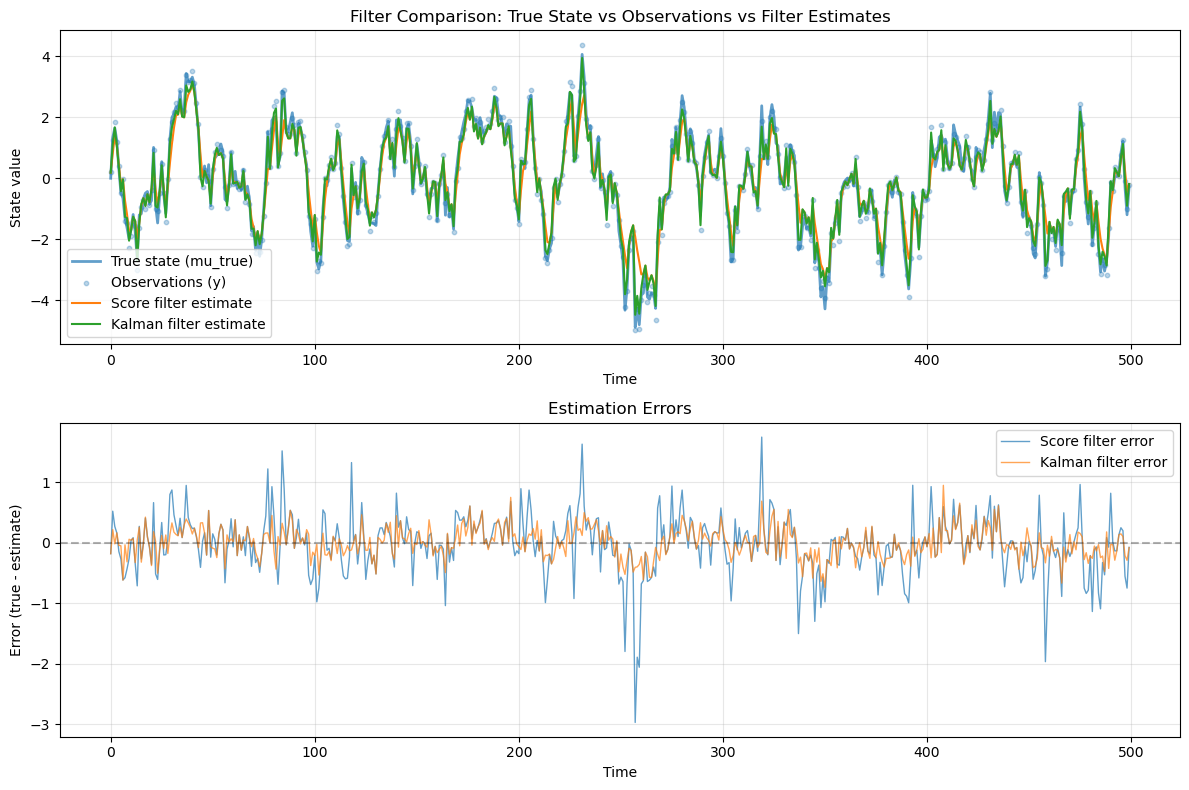

Score filter MSE: 0.2342
Kalman filter MSE: 0.0625


In [21]:
# Plot results
t = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full time series
axes[0].plot(t, mu_true, label="True state (mu_true)", linewidth=2, alpha=0.7)
axes[0].scatter(t, y, label="Observations (y)", alpha=0.3, s=10)
axes[0].plot(t, score_filter.mu, label="Score filter estimate", linewidth=1.5)
axes[0].plot(t, kalman_filter.mu, label="Kalman filter estimate", linewidth=1.5)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("State value")
axes[0].set_title("Filter Comparison: True State vs Observations vs Filter Estimates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Estimation errors
error_score = [mt - ms for mt, ms in zip(mu_true, score_filter.mu)]
error_kalman = [mt - mk for mt, mk in zip(mu_true, kalman_filter.mu)]
axes[1].plot(t, error_score, label="Score filter error", linewidth=1, alpha=0.7)
axes[1].plot(t, error_kalman, label="Kalman filter error", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Error (true - estimate)")
axes[1].set_title("Estimation Errors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score filter MSE: {np.mean(np.array(error_score) ** 2):.4f}")
print(f"Kalman filter MSE: {np.mean(np.array(error_kalman) ** 2):.4f}")